## Лабораторна робота №3
Візуалізація даних


### *1. Завантаження даних та первинний огляд*

In [1]:
import pandas as pd
import numpy as np

path = "data/imports-85.data"

headers = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", 
    "num-of-doors", "body-style", "drive-wheels", "engine-location", 
    "wheel-base", "length", "width", "height", "curb-weight", 
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system", 
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm", 
    "city-mpg", "highway-mpg", "price"
]

df = pd.read_csv(path, names=headers, na_values="?")

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## 2. Здійснення Data Cleaning
### *2.1. Виявлення пропущених значень*

In [2]:
missing_data = df.isnull().sum()
print("Кількість пропусків у кожній колонці:")
print(missing_data[missing_data > 0])

Кількість пропусків у кожній колонці:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


### *2.2. Заповнення числових пропусків середнім значенням*

In [3]:
cols_to_fix = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]

for col in cols_to_fix:
    avg = df[col].astype("float").mean(axis=0)
    df[col] = df[col].fillna(avg)
    print(f"Колонку {col} заповнено середнім: {avg:.2f}")

Колонку normalized-losses заповнено середнім: 122.00
Колонку bore заповнено середнім: 3.33
Колонку stroke заповнено середнім: 3.26
Колонку horsepower заповнено середнім: 104.26
Колонку peak-rpm заповнено середнім: 5125.37


### *2.3. Опрацювання категоріальних пропусків*

In [4]:
most_freq_doors = df['num-of-doors'].value_counts().idxmax()
df["num-of-doors"] = df["num-of-doors"].fillna(most_freq_doors)

print(f"Заповнено num-of-doors значенням: {most_freq_doors}")

Заповнено num-of-doors значенням: four


### *2.4. Видалення рядків без цільової ознаки*

In [5]:
df.dropna(subset=["price"], axis=0, inplace=True)

df.reset_index(drop=True, inplace=True)

print(f"Очищення завершено. Залишилось рядків: {len(df)}")

Очищення завершено. Залишилось рядків: 201


### *2.5. Приведення типів даних до відповідних форматів*

In [6]:
df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")

print(df.dtypes)
df.head()

symboling              int64
normalized-losses      int64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### *2.6. Фінальна перевірка результатів очищення*

In [7]:
print("Загальна кількість пропусків у датасеті:", df.isnull().sum().sum())

print("\nТипи даних після конвертації:")
print(df[["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]].dtypes)

df.head()

Загальна кількість пропусків у датасеті: 0

Типи даних після конвертації:
normalized-losses      int64
bore                 float64
stroke               float64
horsepower           float64
peak-rpm             float64
price                float64
dtype: object


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## 3. Побудування графіка залежності одного integer/real атрибута від іншого (lineplot, scatter etc).
### *3.1. Візуалізація лінійної залежності (Regression Plot)*

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

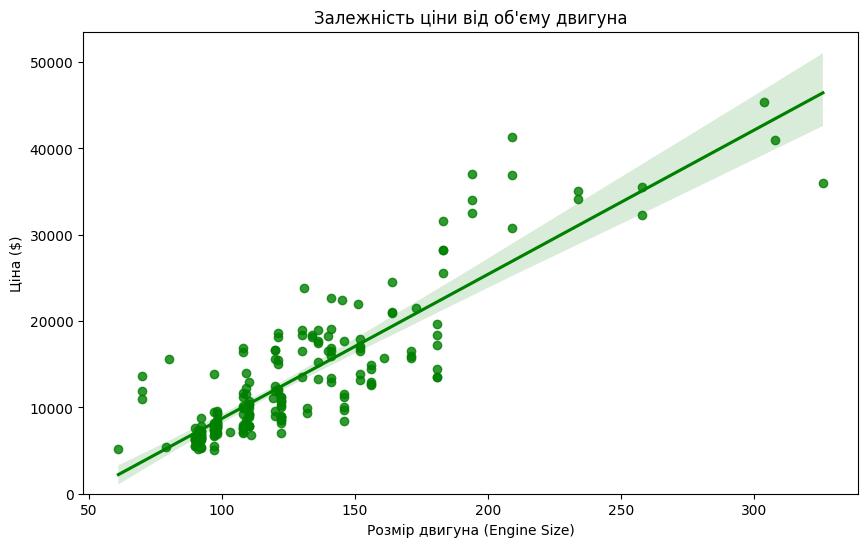

In [9]:
plt.figure(figsize=(10, 6))
sns.regplot(x="engine-size", y="price", data=df, color="g")

plt.title("Залежність ціни від об'єму двигуна")
plt.xlabel("Розмір двигуна (Engine Size)")
plt.ylabel("Ціна ($)")
plt.ylim(0,)
plt.show()

## 4. Побудування гістограми по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 заданих діапазонах

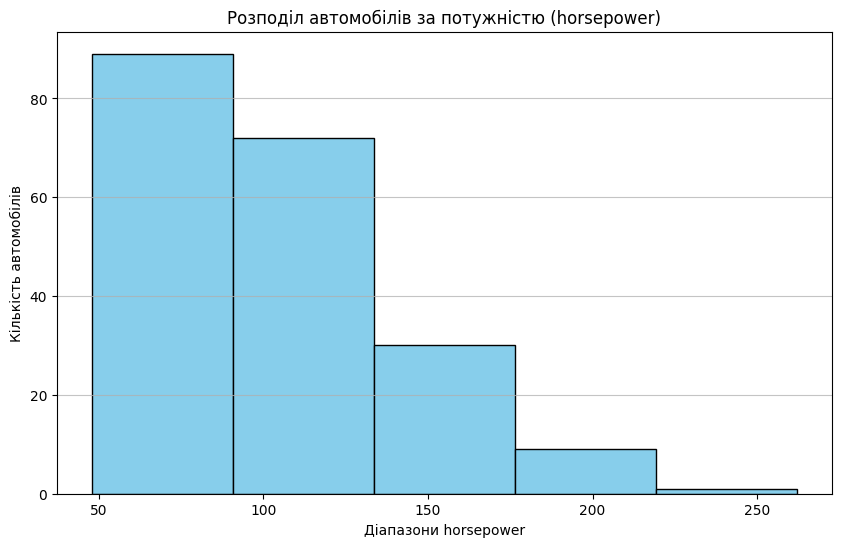

Кількість елементів у кожному діапазоні:
horsepower-binned
Дуже низька    89
Низька         72
Середня        30
Висока          9
Дуже висока     1
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt

attribute = "horsepower"

bins = np.linspace(min(df[attribute]), max(df[attribute]), 6)

group_names = ['Дуже низька', 'Низька', 'Середня', 'Висока', 'Дуже висока']

df[f'{attribute}-binned'] = pd.cut(df[attribute], bins, labels=group_names, include_lowest=True)

plt.figure(figsize=(10, 6))
plt.hist(df[attribute], bins=5, color='skyblue', edgecolor='black')

plt.title(f"Розподіл автомобілів за потужністю ({attribute})")
plt.xlabel(f"Діапазони {attribute}")
plt.ylabel("Кількість автомобілів")

plt.grid(axis='y', alpha=0.75)
plt.show()

print("Кількість елементів у кожному діапазоні:")
print(df[f'{attribute}-binned'].value_counts().sort_index())

## 5. Графіки, що покажуть корисну інформацію про датасет.
### *5.1. Аналіз мультиколінеарності (Heatmap)*

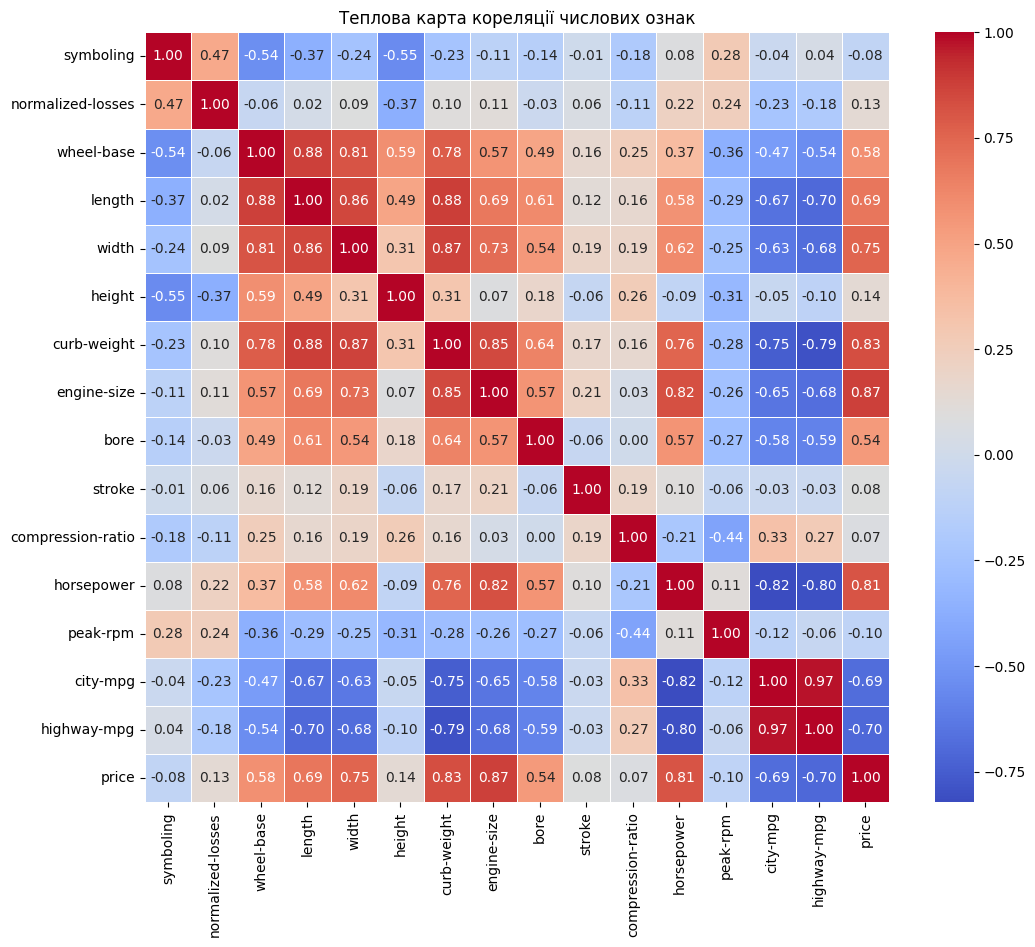

In [11]:
plt.figure(figsize=(12, 10))

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Теплова карта кореляції числових ознак")
plt.show()

### *5.2. Багатовимірний аналіз щільності розподілу (Violin Plot)*

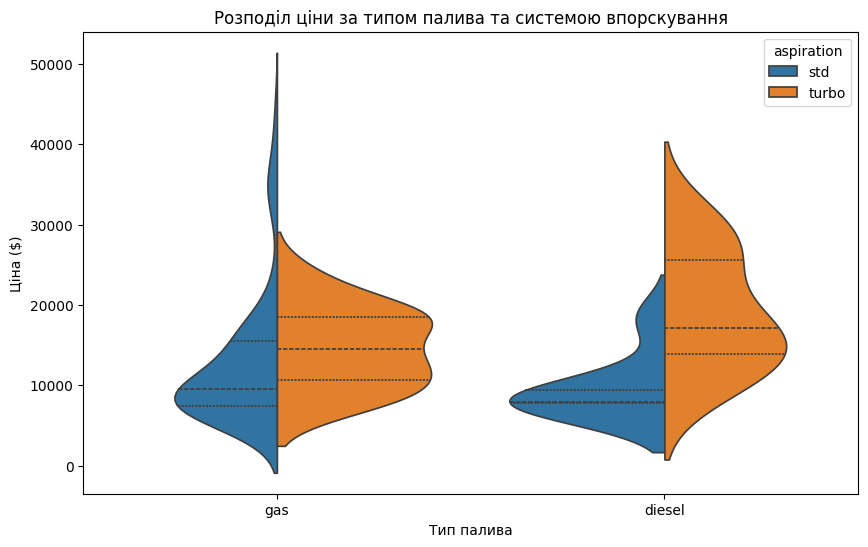

In [12]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="fuel-type", y="price", hue="aspiration", data=df, split=True, inner="quart")

plt.title("Розподіл ціни за типом палива та системою впорскування")
plt.xlabel("Тип палива")
plt.ylabel("Ціна ($)")
plt.show()

### *5.3. Дослідження кореляції та розподілів (Joint Plot)*

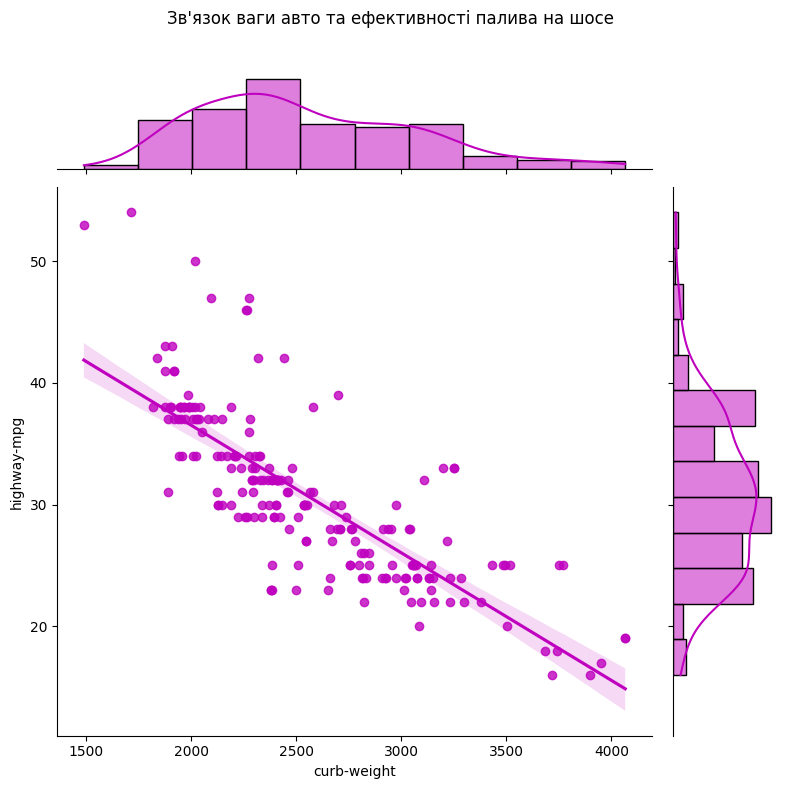

In [13]:
g = sns.jointplot(x="curb-weight", y="highway-mpg", data=df, 
                  kind="reg", color="m", height=8)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Зв'язок ваги авто та ефективності палива на шосе")
plt.show()

### *5.4. Багатовимірний аналіз залежностей (Bubble Chart)*

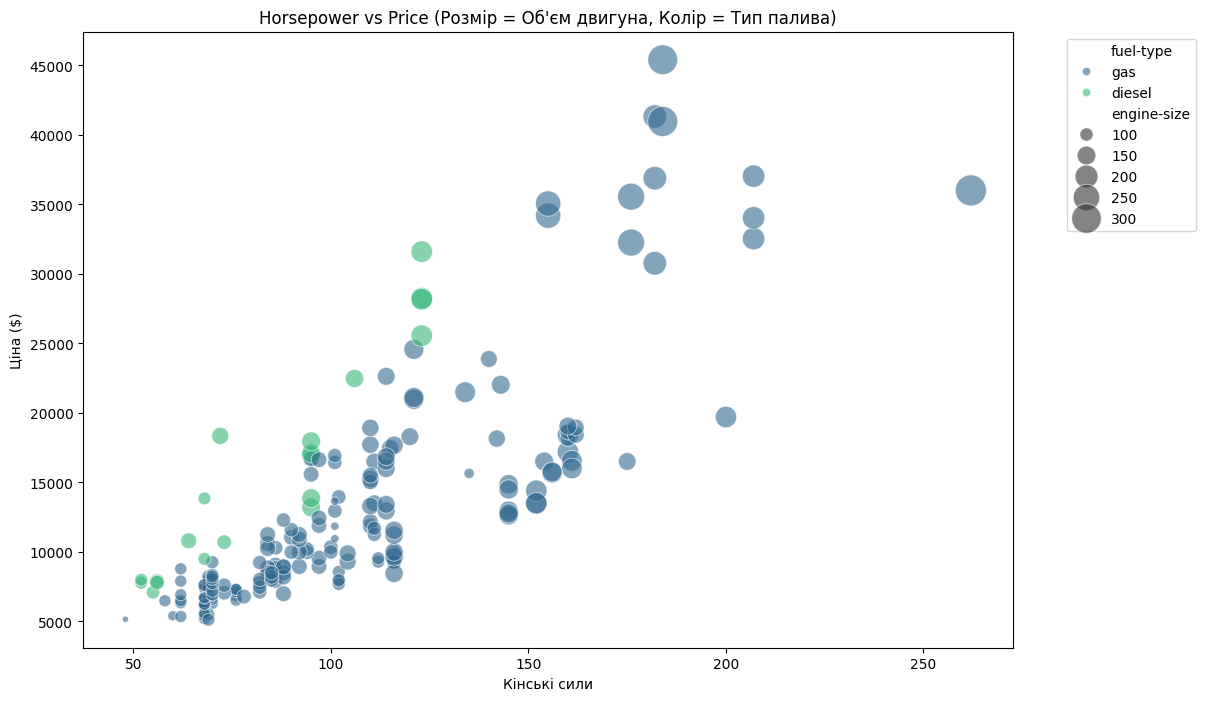

In [14]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="horsepower", y="price", 
                size="engine-size", hue="fuel-type", 
                alpha=0.6, sizes=(20, 500), palette="viridis")

plt.title("Horsepower vs Price (Розмір = Об'єм двигуна, Колір = Тип палива)")
plt.xlabel("Кінські сили")
plt.ylabel("Ціна ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### *5.5. Тривимірна візуалізація ключових характеристик (3D Scatter Plot)*

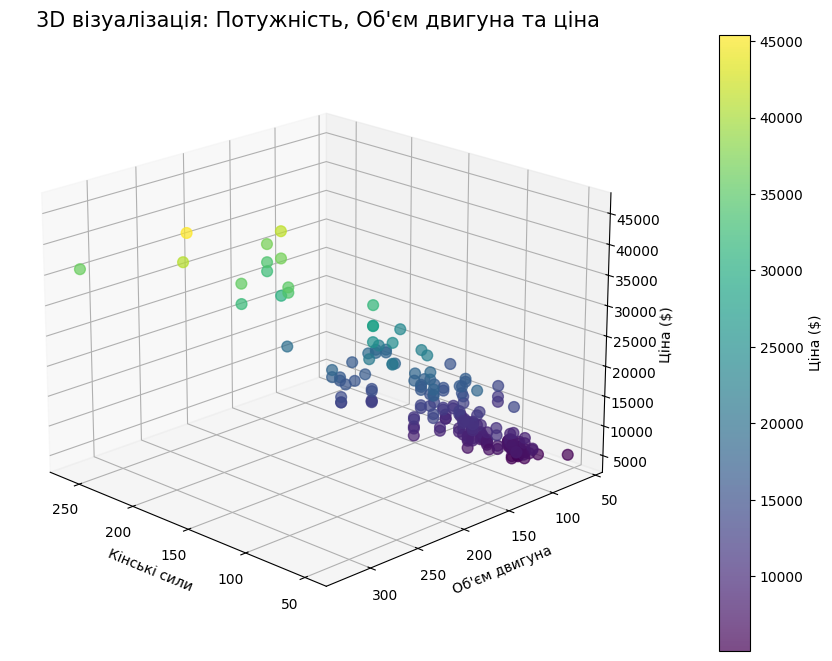

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(111, projection='3d') 

x = df['horsepower']
y = df['engine-size']
z = df['price']

img = ax.scatter(x, y, z, c=z, cmap='viridis', s=60, alpha=0.7)

ax.set_title("3D візуалізація: Потужність, Об'єм двигуна та ціна", fontsize=15)
ax.set_xlabel('Кінські сили')
ax.set_ylabel('Об\'єм двигуна')
ax.set_zlabel('Ціна ($)')

fig.colorbar(img, ax=ax, label='Ціна ($)', pad=0.1)

ax.view_init(elev=20, azim=135)

plt.show()